# 实验五：梯度下降 vs. 牛顿法

## 知识背景回顾

我们已经学习了两种求解无约束优化问题 $\min f(x)$ 的核心迭代算法：

1.  **梯度下降法 (Gradient Descent - GD)** (教材4.2节):
    $$\mathbf{x}^{k+1} = \mathbf{x}^k - \alpha_k \nabla f(\mathbf{x}^k)$$
    它利用函数的一阶导数信息（梯度）$\nabla f(\mathbf{x}^k)$ 来确定下降方向。负梯度方向是函数值**局部**下降最快的方向。

2.  **牛顿法 (Newton's Method)** (教材4.5节):
    $$\mathbf{x}^{k+1} = \mathbf{x}^k - \alpha_k [\nabla^2 f(\mathbf{x}^k)]^{-1} \nabla f(\mathbf{x}^k)$$
    它利用函数的二阶导数信息（Hessian矩阵）$\nabla^2 f(\mathbf{x}^k)$。其核心思想是在当前点 $\mathbf{x}^k$ 附近用一个二次函数来近似 $f(x)$，然后直接跳到这个二次近似函数的最小值点。牛顿方向 $d^k = -[\nabla^2 f(\mathbf{x}^k)]^{-1} \nabla f(\mathbf{x}^k)$ 提供了对最优解位置的更精确估计。

**关键区别**：
* GD 是一阶方法，只看当前点的“坡度”。
* Newton 是二阶方法，同时考虑“坡度”和“曲率”。

**步长/阻尼因子 $\alpha_k$**:
* 对于GD，$\alpha_k$ 是学习率。
* 对于纯牛顿法，理论步长 $\alpha_k=1$。但在实践中，为了保证算法稳定收敛（特别是离最优点较远时），通常会引入**阻尼因子** $\alpha_k \in (0, 1]$，或者使用**线性搜索 (Line Search)** (教材4.4节) 来自动确定一个合适的 $\alpha_k$，使得函数值充分下降。**回溯线性搜索 (Backtracking Line Search)** 是一种常用的策略。

## 实验说明

本次实验旨在通过交互和对比，让你深入理解梯度下降法和牛顿法的性能差异、适用场景和潜在问题。

### 模块一：交互式探索

在这个模块，你可以自由设置参数，在不同的函数上直观对比两种算法的动态路径。

1.  **选择函数**：我们提供了三个具有代表性的测试函数：
    * **简单二次函数**：$f(x, y) = x^2 + y^2$，地形简单，条件良好。
    * **病态二次函数**：$f(x, y) = x^2 + 100y^2$，狭长的椭圆“山谷”，条件数差 (ill-conditioned)。
    * **Rosenbrock 函数**：$f(x, y) = (1-x)^2 + 100(y-x^2)^2$，非二次函数，有一个著名的狭长弯曲“香蕉谷”，优化难度大。
2.  **选择算法**：可以在“梯度下降法”和“牛顿法”之间切换。
3.  **设置参数**：
    * **初始点 $(x_0, y_0)$**：自由选择算法的起点。
    * **学习率 $\alpha$ (GD)** / **阻尼因子 $\alpha$ (Newton)**：手动控制步长大小（若不使用线搜索）。
    * **迭代次数**：控制算法运行的总步数。
    * **使用回溯线搜索?**：勾选此项后，将自动采用回溯法确定每一步的 $\alpha_k$，手动设置的 $\alpha$ 将失效。
4.  **观察路径**：程序会绘制算法在函数等高线图上的迭代路径。请重点观察：
    * 两种算法的路径形态有何不同？
    * 达到相似精度需要多少步？
    * 在病态函数上，哪种算法表现更好？为什么？
    * 手动调节 $\alpha$ 对两种算法分别有什么影响？

### 模块二：预设案例分析

这个模块将展示在**开启回溯线性搜索**的情况下，两种算法在特定函数和起点下的典型表现。

* **案例一：病态二次函数**：对比 GD 的“之”字形慢收敛和 Newton 的高效收敛。
* **案例二：Rosenbrock 函数**：对比 GD 在“香蕉谷”中的挣扎和 Newton 在接近最优解时的快速二次收敛。
* **案例三：牛顿法的潜在风险**：展示在**不使用**线搜索或阻尼时，牛顿法可能因为步长过大或方向错误而发散的情况。

通过这两个模块的探索和分析，你将能更深刻地理解梯度下降法和牛顿法的核心差异、计算成本、收敛速度以及稳定性问题。

In [13]:
# 导入所有需要的库
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown, FloatSlider, IntSlider, Checkbox, VBox, HBox, interactive_output, Layout
import warnings
plt.rcParams['font.sans-serif'] = ['SimHei']  # 正确显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 正确显示负号

# 忽略数值计算中可能出现的警告
warnings.filterwarnings("ignore") 

# --- 数据准备：定义函数、梯度、Hessian ---

# 1. 简单二次函数
def quadratic_simple(x, y): return x**2 + y**2
def quadratic_simple_grad(x, y): return np.array([2*x, 2*y])
def quadratic_simple_hess(x, y): return np.array([[2.0, 0.0], [0.0, 2.0]])

# 2. 病态二次函数
def quadratic_ill(x, y): return x**2 + 100*y**2
def quadratic_ill_grad(x, y): return np.array([2*x, 200*y])
def quadratic_ill_hess(x, y): return np.array([[2.0, 0.0], [0.0, 200.0]])

# 3. Rosenbrock 函数
def rosenbrock(x, y): return (1 - x)**2 + 100 * (y - x**2)**2
def rosenbrock_grad(x, y):
    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)
    return np.array([dx, dy])
def rosenbrock_hess(x, y):
    h11 = 2 - 400*y + 1200*x**2
    h12 = -400*x
    h21 = -400*x
    h22 = 200.0
    return np.array([[h11, h12], [h21, h22]])

# 将函数信息打包，并为交互模块配置参数范围
functions = {
    "简单二次函数": {
        "func": quadratic_simple, "grad": quadratic_simple_grad, "hess": quadratic_simple_hess,
        "x_range": (-5, 5), "y_range": (-5, 5), "levels": 20,
        "x_start_params": {'min': -5.0, 'max': 5.0, 'value': 4.0},
        "y_start_params": {'min': -5.0, 'max': 5.0, 'value': 3.0},
        "gd_lr_params": {'min': 0.01, 'max': 0.99, 'step': 0.01, 'value': 0.1, 'readout_format': '.2f'},
        "newton_damp_params": {'min': 0.01, 'max': 1.0, 'step': 0.01, 'value': 1.0, 'readout_format': '.2f'}
    },
    "病态二次函数": {
        "func": quadratic_ill, "grad": quadratic_ill_grad, "hess": quadratic_ill_hess,
        "x_range": (-5, 5), "y_range": (-1, 1), "levels": 30,
        "x_start_params": {'min': -5.0, 'max': 5.0, 'value': 4.0},
        "y_start_params": {'min': -1.0, 'max': 1.0, 'value': 0.8},
        "gd_lr_params": {'min': 0.001, 'max': 0.015, 'step': 0.001, 'value': 0.005, 'readout_format': '.3f'},
        "newton_damp_params": {'min': 0.01, 'max': 1.0, 'step': 0.01, 'value': 1.0, 'readout_format': '.2f'}
    },
    "Rosenbrock函数": {
        "func": rosenbrock, "grad": rosenbrock_grad, "hess": rosenbrock_hess,
        "x_range": (-2, 2), "y_range": (-1, 3), "levels": np.logspace(-0.5, 3.5, 20, base=10), # 对数间隔等高线
        "x_start_params": {'min': -2.0, 'max': 2.0, 'value': -1.5},
        "y_start_params": {'min': -1.0, 'max': 3.0, 'value': 2.0},
        "gd_lr_params": {'min': 0.0001, 'max': 0.005, 'step': 0.0001, 'value': 0.001, 'readout_format': '.4f'},
        "newton_damp_params": {'min': 0.01, 'max': 1.0, 'step': 0.01, 'value': 1.0, 'readout_format': '.2f'}
    }
}

# --- 核心算法实现 ---

def backtracking_line_search(func, grad_func, xk, pk, alpha_init=1.0, rho=0.5, c=1e-4):
    """回溯线性搜索实现 (满足 Armijo 条件)"""
    alpha = alpha_init
    fk = func(xk[0], xk[1])
    grad_k = grad_func(xk[0], xk[1])
    
    # 检查 Armijo 条件: f(xk + alpha*pk) <= f(xk) + c * alpha * grad(xk)^T * pk
    while func(xk[0] + alpha * pk[0], xk[1] + alpha * pk[1]) > fk + c * alpha * np.dot(grad_k, pk):
        alpha *= rho
        if alpha < 1e-10: # 防止步长过小
             return alpha
    return alpha

def run_gd(func, grad_func, start_point, learning_rate, n_iterations, use_line_search=False):
    """执行梯度下降"""
    path = [start_point]
    point = np.array(start_point, dtype=float)
    for k in range(n_iterations):
        grad = grad_func(point[0], point[1])
        pk = -grad
        
        alpha = learning_rate
        if use_line_search:
            alpha = backtracking_line_search(func, grad_func, point, pk, alpha_init=1.0) # GD线搜索初始步长设为1
            
        point = point + alpha * pk
        path.append(point.copy())
        # 简单的停止条件：如果梯度很小
        if np.linalg.norm(grad) < 1e-6:
            break
    return np.array(path)

def run_newton(func, grad_func, hess_func, start_point, damping_factor, n_iterations, use_line_search=False):
    """执行牛顿法"""
    path = [start_point]
    point = np.array(start_point, dtype=float)
    for k in range(n_iterations):
        grad = grad_func(point[0], point[1])
        hess = hess_func(point[0], point[1])
        
        try:
            # 计算牛顿方向 pk = -H^(-1) * grad
            hess_inv = np.linalg.inv(hess)
            pk = -np.dot(hess_inv, grad)
        except np.linalg.LinAlgError:
            # 如果 Hessian 不可逆或计算出错，可以退化为梯度下降
            print(f"警告: 第 {k+1} 步 Hessian 矩阵奇异，使用负梯度方向替代。")
            pk = -grad

        alpha = damping_factor
        if use_line_search:
            # 对于牛顿法，理论最优步长是1，所以线搜索从1开始
            alpha = backtracking_line_search(func, grad_func, point, pk, alpha_init=1.0) 

        point = point + alpha * pk
        path.append(point.copy())
        # 简单的停止条件：如果梯度很小或步长很小
        step_norm = np.linalg.norm(alpha * pk)
        if np.linalg.norm(grad) < 1e-6 or step_norm < 1e-8:
            break
            
    return np.array(path)

In [ ]:
# --- 模块一：交互式探索 ---

# 绘图函数
def interactive_plotter(func_name, algorithm, x_start, y_start, alpha_manual, iterations, use_line_search):
    info = functions[func_name]
    func, grad_func, hess_func = info["func"], info["grad"], info["hess"]
    x_range, y_range = info["x_range"], info["y_range"]
    
    start_point = (x_start, y_start)
    
    # 根据选择运行算法
    if algorithm == "梯度下降法":
        path = run_gd(func, grad_func, start_point, alpha_manual, iterations, use_line_search)
    elif algorithm == "牛顿法":
        path = run_newton(func, grad_func, hess_func, start_point, alpha_manual, iterations, use_line_search)
    else:
        path = np.array([start_point]) # Fallback

    # 绘图
    plt.figure(figsize=(9, 7))
    x_plot = np.linspace(x_range[0], x_range[1], 300)
    y_plot = np.linspace(y_range[0], y_range[1], 300)
    X, Y = np.meshgrid(x_plot, y_plot)
    Z = func(X, Y)
    
    plt.contour(X, Y, Z, levels=info["levels"], cmap='viridis')
    plt.plot(path[:, 0], path[:, 1], '-o', color='red', markersize=3, label=f'{algorithm} 优化路径')
    plt.plot(start_point[0], start_point[1], 'go', markersize=10, label='起始点')
    
    # 标记最优解（如果已知）
    if func_name == "Rosenbrock函数":
        plt.plot(1, 1, 'r*', markersize=15, label='Optimum (1,1)')
    elif "二次" in func_name:
         plt.plot(0, 0, 'r*', markersize=15, label='Optimum (0,0)')

    plt.xlabel('x')
    plt.ylabel('y')
    title = f'函数: {func_name} | 算法: {algorithm}\n'
    if use_line_search:
        title += f'使用回溯线搜索 | 迭代 {len(path)-1} 步'
    else:
        title += f'固定 α={alpha_manual:.4f} | 迭代 {len(path)-1} 步'
    plt.title(title)
    
    plt.legend(loc='best')
    plt.grid(True)
    plt.xlim(x_range)
    plt.ylim(y_range)
    plt.gca().set_aspect('auto', adjustable='box') # 保持坐标轴范围优先
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # 为图例留出空间
    plt.show()

# 创建交互式控件
func_name_w = Dropdown(options=functions.keys(), description='选择函数:')
algo_w = Dropdown(options=["梯度下降法", "牛顿法"], description='选择算法:')
x_start_w = FloatSlider(description='初始点 x₀:')
y_start_w = FloatSlider(description='初始点 y₀:')
alpha_manual_w = FloatSlider(description='学习/阻尼 α:') # 这个滑杆描述会动态改变
iterations_w = IntSlider(min=1, max=500, step=1, value=50, description='迭代次数:', layout=Layout(width='50%'))
use_ls_w = Checkbox(value=True, description='使用回溯线搜索?', indent=False)

# 3. 定义滑杆更新函数 (修改内部逻辑)
def update_sliders_and_labels(*args):
    params = functions[func_name_w.value]

    # 更新起点滑杆范围 (保持之前的修复逻辑：max -> min -> value)
    for key, slider in {'x_start_params': x_start_w, 'y_start_params': y_start_w}.items():
        slider_params = params[key]
        if 'max' in slider_params: slider.max = slider_params['max']
        if 'min' in slider_params: slider.min = slider_params['min']
        if 'value' in slider_params: slider.value = max(slider.min, min(slider.max, slider_params['value']))
        for attr, value in slider_params.items():
            if attr not in ['min', 'max', 'value']: setattr(slider, attr, value)

    # ----- 更新手动 alpha 滑杆范围和描述 -----
    if algo_w.value == "梯度下降法":
        alpha_params = params["gd_lr_params"]
        alpha_manual_w.description = '学习率 α:'
    else: # 牛顿法
        alpha_params = params["newton_damp_params"]
        alpha_manual_w.description = '阻尼因子 α:'

    # 获取新的范围和值
    new_min = alpha_params.get('min', alpha_manual_w.min)
    new_max = alpha_params.get('max', alpha_manual_w.max)
    new_value = alpha_params.get('value', alpha_manual_w.value)

    try:
        if new_max < alpha_manual_w.min:
            # 如果新 max 比当前 min 还小，必须先更新 min
            alpha_manual_w.min = new_min
            alpha_manual_w.max = new_max
        else:
            # 否则，先更新 max 通常更安全（能避免 min > max 错误）
            alpha_manual_w.max = new_max
            alpha_manual_w.min = new_min
    except TraitError as e:
        # 添加一个后备方案，以防万一还有其他边界情况
        print(f"在更新滑杆范围时遇到 TraitError: {e}. 尝试重置范围。")
        # 尝试设置一个非常宽的范围，然后再设置目标范围
        try:
            alpha_manual_w.min = min(new_min, alpha_manual_w.min) - abs(new_min) # 确保小于 new_min
            alpha_manual_w.max = max(new_max, alpha_manual_w.max) + abs(new_max) # 确保大于 new_max
            alpha_manual_w.max = new_max
            alpha_manual_w.min = new_min
        except TraitError as e2:
             print(f"重置范围失败: {e2}. 滑杆范围可能不正确。")


    # 更新 value, 确保在最终的 [min, max] 内
    alpha_manual_w.value = max(alpha_manual_w.min, min(alpha_manual_w.max, new_value))

    # 更新其他属性 (step, readout_format)
    for attr, value in alpha_params.items():
        if attr not in ['min', 'max', 'value']:
            setattr(alpha_manual_w, attr, value)

    # 根据是否使用线搜索，决定是否禁用手动alpha滑杆
    alpha_manual_w.disabled = use_ls_w.value



# 4. 绑定更新函数到下拉菜单
func_name_w.observe(update_sliders_and_labels, 'value')
algo_w.observe(update_sliders_and_labels, 'value')
use_ls_w.observe(update_sliders_and_labels, 'value')

# 5. 初始化滑杆状态 (保持不变)
update_sliders_and_labels()

# 6. 将UI控件和绘图函数连接起来 (保持不变)
interactive_app = interactive_output(interactive_plotter, {
    'func_name': func_name_w, 'algorithm': algo_w,
    'x_start': x_start_w, 'y_start': y_start_w,
    'alpha_manual': alpha_manual_w, 'iterations': iterations_w,
    'use_line_search': use_ls_w
})

# 7. 显示UI界面和图形 (保持不变)
display(VBox([
    HBox([func_name_w, algo_w]),
    HBox([x_start_w, y_start_w]),
    HBox([alpha_manual_w, use_ls_w]),
    iterations_w,
    interactive_app
]))

In [15]:
# --- 模块二：预设案例分析 ---

def plot_preset_comparison(fig, axes, func_info, start_point, n_iterations, case_title):
    """绘制GD和Newton在同一函数上的对比图 (带线搜索)"""
    func, grad_func, hess_func = func_info["func"], func_info["grad"], func_info["hess"]
    x_range, y_range = func_info["x_range"], func_info["y_range"]
    
    # 运行算法 (固定使用线搜索)
    path_gd = run_gd(func, grad_func, start_point, 0.0, n_iterations, use_line_search=True) # learning_rate 无效
    path_newton = run_newton(func, grad_func, hess_func, start_point, 0.0, n_iterations, use_line_search=True) # damping_factor 无效
    
    # 绘制等高线
    x_plot = np.linspace(x_range[0], x_range[1], 300)
    y_plot = np.linspace(y_range[0], y_range[1], 300)
    X, Y = np.meshgrid(x_plot, y_plot)
    Z = func(X, Y)
    
    # 绘制路径
    for ax, path, algo_name, color in zip(axes, [path_gd, path_newton], ["梯度下降", "牛顿法"], ["blue", "red"]):
        ax.contour(X, Y, Z, levels=func_info["levels"], cmap='viridis')
        ax.plot(path[:, 0], path[:, 1], '-o', color=color, markersize=3, label=f'{algo_name} ({len(path)-1} 步)')
        ax.plot(start_point[0], start_point[1], 'go', markersize=10, label='起点')
        if "Rosenbrock" in case_title: ax.plot(1, 1, 'k*', markersize=15, label='最优点')
        elif "二次" in case_title: ax.plot(0, 0, 'k*', markersize=15, label='最优点')

        ax.set_title(f'{algo_name} on {case_title}')
        ax.set_xlabel('x'); ax.set_ylabel('y'); ax.grid(True)
        ax.legend(); ax.set_xlim(x_range); ax.set_ylim(y_range)
        ax.set_aspect('auto', adjustable='box')



**案例一说明：病态二次函数 ($x^2 + 100y^2$)**
* **梯度下降 (左图)**：由于函数的等高线是狭长的椭圆，梯度方向（垂直于等高线）大部分情况下并不指向最优点(0,0)。导致GD路径呈现典型的“之”字形震荡，收敛缓慢（线性收敛）。
* **牛顿法 (右图)**：牛顿法通过乘以Hessian矩阵的逆 $[\nabla^2 f]^{-1}$ 对梯度进行了“尺度缩放”和“方向矫正”。对于二次函数，这个矫正使得牛顿方向正好指向最小值点。理论上一步收敛，图中可能需要2-3步是由于线搜索和数值精度影响。这体现了牛顿法的**仿射不变性**和**二次收敛**速度。
* **成本考量**：虽然牛顿法步数少，但每一步都需要计算Hessian矩阵并求逆，成本远高于GD。

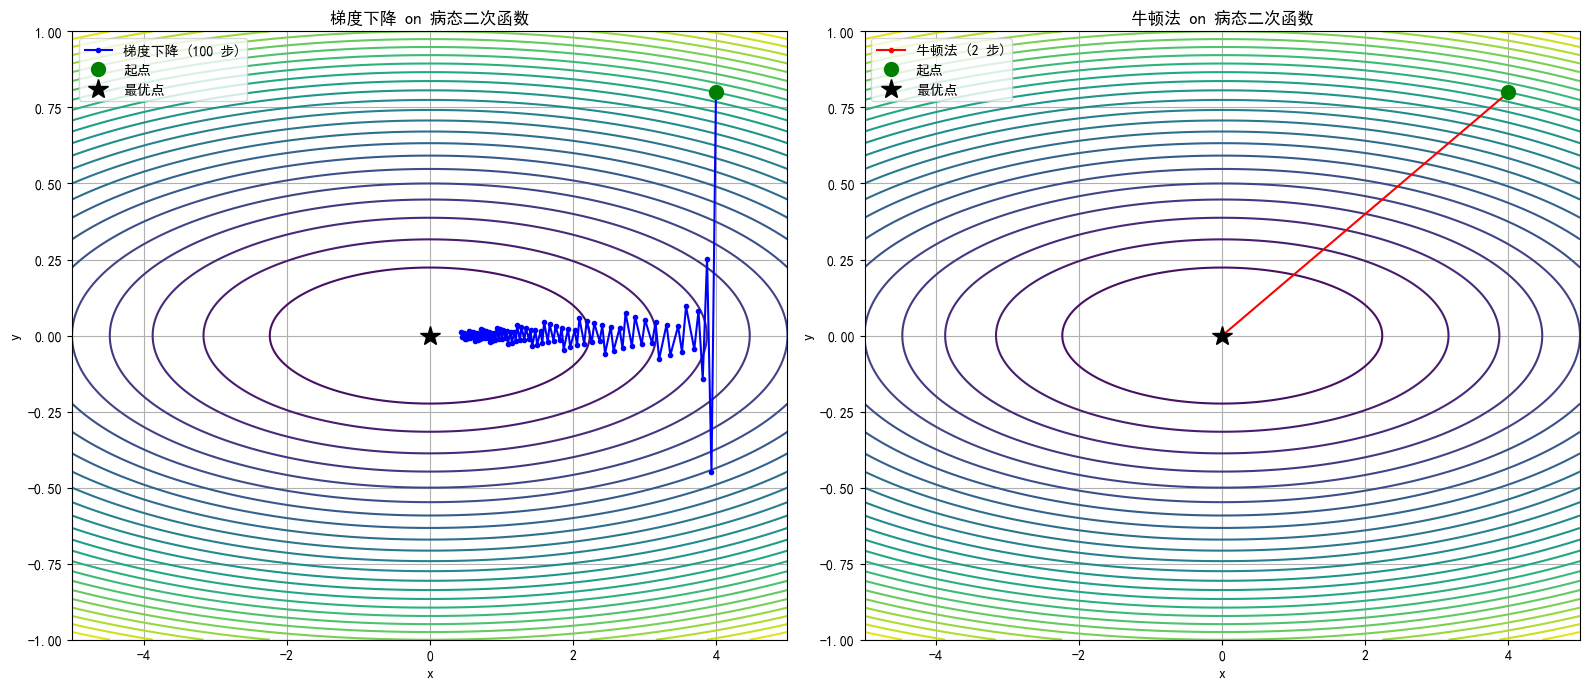

In [16]:
# 案例一：病态二次函数
fig_case1, axes_case1 = plt.subplots(1, 2, figsize=(16, 7))
ill_info = functions["病态二次函数"]
start_pt_ill = (4.0, 0.8)
plot_preset_comparison(fig_case1, axes_case1, ill_info, start_pt_ill, 100, "病态二次函数")
plt.tight_layout()
plt.show()




**案例二说明：Rosenbrock 函数**
* **梯度下降 (左图)**：在著名的“香蕉谷”中，GD的进展非常缓慢。即使使用了线搜索，也很难快速沿着谷底移动，因为它总是在陡峭的“谷壁”之间小步震荡。
* **牛顿法 (右图)**：牛顿法初始几步可能因为函数非二次性而略有调整（线搜索起了作用），但一旦接近最优解 (1,1) 附近，其二次收敛特性使其能迅速逼近目标。
* **结论**：对于非二次的病态问题，牛顿法（配合线搜索）在收敛速度上通常仍有巨大优势，尤其是在最优解附近。但其高昂的单步计算成本（特别是在高维问题中）催生了**拟牛顿法**（如BFGS）的研究。


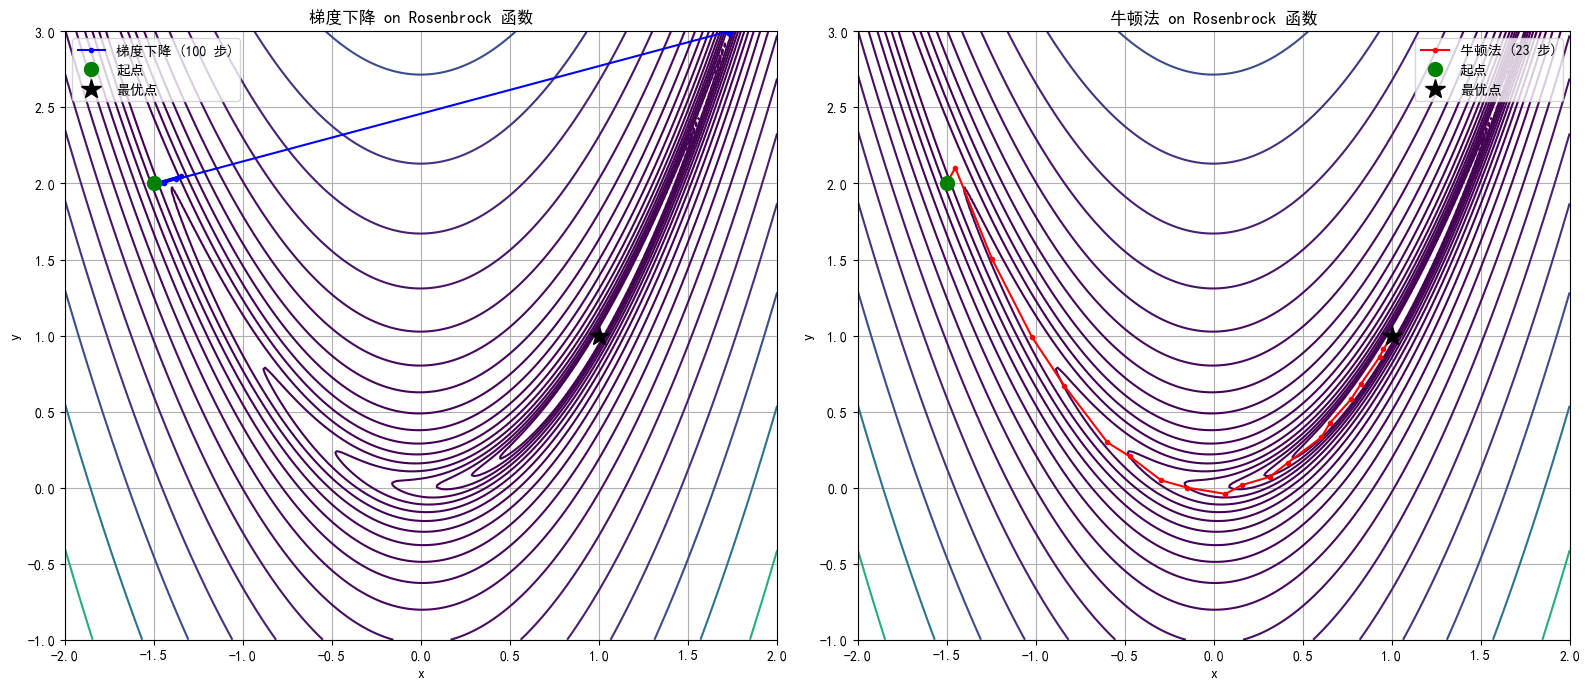

In [17]:
# 案例二：Rosenbrock 函数
fig_case2, axes_case2 = plt.subplots(1, 2, figsize=(16, 7))
rosen_info = functions["Rosenbrock函数"]
start_pt_rosen = (-1.5, 2.0)
plot_preset_comparison(fig_case2, axes_case2, rosen_info, start_pt_rosen, 100, "Rosenbrock 函数")
plt.tight_layout()
plt.show()




**案例三说明：牛顿法的潜在风险**
* **现象**：图中展示了从一个特定起点出发，使用纯牛顿步 ($\alpha=1$，无回溯线搜索) 的情况。可以看到，迭代点迅速跑到了远离最优解的地方，呈现发散趋势。
* **原因**：牛顿法依赖于函数在当前点的**局部二次近似**。当距离最优点较远，或者Hessian矩阵非正定（例如在鞍点或非凸区域）时，这个二次近似可能很差。纯牛顿步（二次模型的最小值点）可能指向一个函数值**更高**的点，或者步长**过大**，导致算法不稳定甚至发散。
* **结论**：这个案例凸显了**阻尼**或**线搜索**对于保证牛顿法**全局收敛性**的重要性。它们通过限制步长或确保函数值充分下降，使得牛顿法即使在初始阶段也能稳定地向最优解靠近。


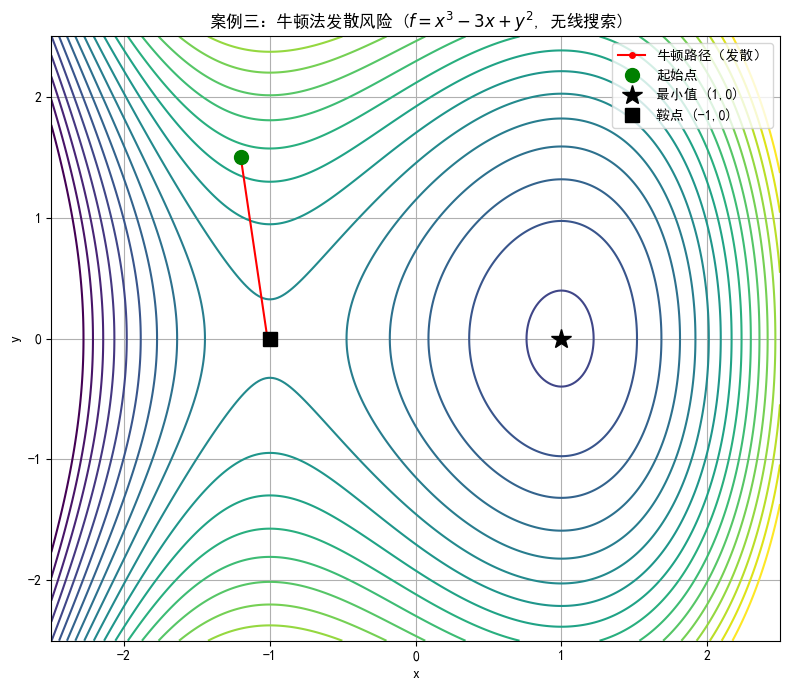

In [18]:
#这个函数只有案例三用到，单独列出在这里
def cubic_func(x, y): return x**3 - 3*x + y**2
def cubic_grad(x, y): return np.array([3*x**2 - 3, 2*y])
def cubic_hess(x, y): return np.array([[6*x, 0.0], [0.0, 2.0]])

# 案例三：牛顿法发散的可能性 (使用新函数)
fig_case3, ax_case3 = plt.subplots(figsize=(8, 7))

# 定义新函数的信息
cubic_info = {
    "func": cubic_func, "grad": cubic_grad, "hess": cubic_hess,
    "x_range": (-2.5, 2.5), "y_range": (-2.5, 2.5),
    "levels": np.linspace(-5, 10, 20) # 调整等高线范围
}
# 选择一个新的起始点
start_pt_diverge = (-1.2, 1.5)
# 运行纯牛顿法
path_newton_diverge = run_newton(cubic_info["func"], cubic_info["grad"], cubic_info["hess"],
                                 start_pt_diverge, damping_factor=1.0, n_iterations=10, use_line_search=False) # 固定 alpha=1

# 绘图
x_plot = np.linspace(cubic_info["x_range"][0], cubic_info["x_range"][1], 300)
y_plot = np.linspace(cubic_info["y_range"][0], cubic_info["y_range"][1], 300)
X, Y = np.meshgrid(x_plot, y_plot)
Z = cubic_info["func"](X, Y)

ax_case3.contour(X, Y, Z, levels=cubic_info["levels"], cmap='viridis')
ax_case3.plot(path_newton_diverge[:, 0], path_newton_diverge[:, 1], '-o', color='red', markersize=4, label='牛顿路径（发散）')
ax_case3.plot(start_pt_diverge[0], start_pt_diverge[1], 'go', markersize=10, label='起始点')
# 标记局部最小值和鞍点
ax_case3.plot(1, 0, 'k*', markersize=15, label='最小值 (1,0)')
ax_case3.plot(-1, 0, 'ks', markersize=10, label='鞍点 (-1,0)') # 用方形标记鞍点

ax_case3.set_title('案例三：牛顿法发散风险 ($f=x^3-3x+y^2$, 无线搜索)')
ax_case3.set_xlabel('x'); ax_case3.set_ylabel('y'); ax_case3.grid(True)
ax_case3.legend();
ax_case3.set_xlim(cubic_info["x_range"]); ax_case3.set_ylim(cubic_info["y_range"])
ax_case3.set_aspect('auto', adjustable='box')
plt.tight_layout()
plt.show()